<a href="https://colab.research.google.com/github/anuj0407/Machine_Learning/blob/Project/02_Loan_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as plo


In [4]:
df = pd.read_csv("/content/hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv")

In [5]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

*New dataframe for required coloumns*

In [7]:
new_df = df[["Loan_Amount","Loan_Term_Months","Applicant_Income","Coapplicant_Income","Existing_EMIs"]].copy()
new_df.reset_index()


,index,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs
0,0,8031545,360,56976,0,5610
1,1,899361,240,1856,0,9166
2,2,2387748,60,64553,0,0
3,3,658856,12,88450,0,26613
4,4,198671,36,9539,0,0
...,...,...,...,...,...,...
995,995,5883603,360,44713,0,5165
996,996,2780228,300,70886,0,20102
997,997,301249,24,24392,11337,34514
998,998,719891,48,64803,94136,34000


In [8]:
new_df["Monthly_Income"] = new_df["Applicant_Income"] + new_df["Coapplicant_Income"]
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income
0,8031545,360,56976,0,5610,56976
1,899361,240,1856,0,9166,1856
2,2387748,60,64553,0,0,64553
3,658856,12,88450,0,26613,88450
4,198671,36,9539,0,0,9539


In [9]:
Std_Interest_rate = 12
new_df["Annual_Intrest"] = (new_df["Loan_Amount"]*Std_Interest_rate*1)/100
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest
0,8031545,360,56976,0,5610,56976,963785.40
1,899361,240,1856,0,9166,1856,107923.32
2,2387748,60,64553,0,0,64553,286529.76
3,658856,12,88450,0,26613,88450,79062.72
4,198671,36,9539,0,0,9539,23840.52


In [10]:
# Annual revenue of Bank
bank_annual_revenue = new_df["Annual_Intrest"].sum()
print("Annual revenue of Bank :",bank_annual_revenue)

Annual revenue of Bank : 266005548.12


In [11]:
# Annual risk for Bank
annual_risk = new_df["Existing_EMIs"].sum()*12
print("Annual risk of Bank :",annual_risk)

Annual risk of Bank : 218080680


In [12]:
# Defined Portfolio utility function
new_df["U"] = new_df["Annual_Intrest"] - (new_df["Existing_EMIs"]*12)
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U
0,8031545,360,56976,0,5610,56976,963785.40,896465.40
1,899361,240,1856,0,9166,1856,107923.32,-2068.68
2,2387748,60,64553,0,0,64553,286529.76,286529.76
3,658856,12,88450,0,26613,88450,79062.72,-240293.28
4,198671,36,9539,0,0,9539,23840.52,23840.52


In [13]:
# Calculate dU_dL
new_df["dU"] = new_df["U"].diff()
new_df["dL"] = new_df["Loan_Amount"].diff()
new_df["dU_dL"] = new_df["dU"] / new_df["dL"]
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973


In [14]:
# Statistical behaviour of all coloumns
new_df.describe()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL
count,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,9.990000e+02,9.990000e+02,999.000000
mean,2.216713e+06,159.132000,42430.057000,9727.11400,18173.390000,52157.171000,2.660055e+05,4.792487e+04,-1.072928e+03,-7.978505e+03,-0.064928
std,2.635021e+06,127.056704,28133.210769,20568.25945,16298.460525,39371.208558,3.162025e+05,3.751737e+05,5.282316e+05,3.696509e+06,3.742956
min,1.884000e+03,12.000000,0.000000,0.00000,0.000000,0.000000,2.260800e+02,-8.115139e+05,-1.706382e+06,-1.357606e+07,-93.948384
25%,3.729465e+05,36.000000,18260.000000,0.00000,1741.750000,21996.000000,4.475358e+04,-2.008963e+05,-3.279934e+05,-1.462870e+06,0.012909
50%,9.720460e+05,120.000000,40675.500000,0.00000,16289.500000,45937.000000,1.166455e+05,6.776280e+03,1.401000e+03,7.518900e+04,0.120000
75%,3.315038e+06,300.000000,61037.250000,7956.50000,29718.500000,71379.000000,3.978045e+05,2.217175e+05,3.070868e+05,1.609360e+06,0.211270
max,1.379096e+07,360.000000,149266.000000,123461.00000,82436.000000,212945.000000,1.654915e+06,1.406754e+06,1.452654e+06,1.108638e+07,20.101352


NumPy Concepts
Use:
- np.sum()
- np.argmax()
- np.argmin()


In [15]:
# np.sum() use
total_customer_income = np.sum(new_df["Applicant_Income"])
print("Total income of all customers :",total_customer_income)

Total income of all customers : 42430057


In [16]:
# np.argmax() use
maximum_loan_amount = np.argmax(new_df["Loan_Amount"])
print("Maximum loan amount index:",maximum_loan_amount) # index of maximum loan amount

Maximum loan amount index: 874


In [17]:
# np.argmin() use
minimum_loan_amount = np.argmin(new_df["Loan_Amount"])
print("Minimum loan amount index:",minimum_loan_amount) # index of minimum loan amount

Minimum loan amount index: 63


# Task 1
Create an affordability metric.
Example:
- Affordability Ratio = Monthly Obligations / Monthly Income


In [36]:
new_df["Affordability_Ratio"] = round(((new_df["Annual_Intrest"]/12) +new_df["Existing_EMIs"])/new_df["Monthly_Income"],2)
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.51,very high
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.78,medium
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.37,very high
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.38,medium
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.21,low


# Task 2
Create revenue estimates for different loan ranges.


In [20]:
loan_bins = [0,400000,1000000,2000000,np.inf]
loan_labels = ["low","medium","high","very high"]
new_df["Loan_Range"] = pd.cut(new_df["Loan_Amount"],bins=loan_bins,labels=loan_labels)
new_df.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very high
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,medium
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,very high
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,medium
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low


In [23]:
revenue_estimates = new_df.groupby("Loan_Range",observed = True)["Annual_Intrest"].mean()
print("Revenue Estimates for Different Loan Ranges:",revenue_estimates)


Revenue Estimates for Different Loan Ranges: Loan_Range
low           26208.322941
medium        75779.899404
high         175463.665823
very high    636851.787224
Name: Annual_Intrest, dtype: float64


# Task 3
Create a utility function balancing:
- Revenue
- Affordability
- Risk



In [64]:
clean_df = new_df[np.isfinite(new_df["Affordability_Ratio"])].copy()

min_revenue = clean_df["Annual_Intrest"].min()
max_revenue = clean_df["Annual_Intrest"].max()
clean_df["norm_revenue"] = (clean_df["Annual_Intrest"] - min_revenue) / (max_revenue - min_revenue)
min_aff = clean_df["Affordability_Ratio"].min()
max_aff = clean_df["Affordability_Ratio"].max()
clean_df["norm_affordability"] = (clean_df["Affordability_Ratio"] - min_aff) / (max_aff - min_aff)
clean_df["util_function"] = (clean_df["norm_revenue"] - clean_df["norm_affordability"])
clean_df.head(5)


,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range,norm_revenue,util_function,norm_affordability
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.51,very high,0.582320,0.571377,0.010944
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.78,medium,0.065086,-0.005794,0.070880
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.37,very high,0.173026,0.170344,0.002682
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.38,medium,0.047644,0.044890,0.002754
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.21,low,0.014271,0.012749,0.001522


# Task 4
Compute first derivatives using numerical methods.


In [70]:
new_df["dU_dL_using_gradient"] = np.gradient(new_df["dU"],new_df["dL"])
new_df

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly_Income,Annual_Intrest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range,norm_revenue,util_function,norm_affordability,dU_dL_using_gradient
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.51,very high,0.582320,0.582320,0.0,NaN
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.78,medium,0.065086,0.065086,0.0,NaN
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.37,very high,0.173026,0.173026,0.0,0.322366
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.38,medium,0.047644,0.047644,0.0,0.864331
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.21,low,0.014271,0.014271,0.0,-0.139017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.43,very high,0.426549,0.426549,0.0,-0.150422
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.68,very high,0.201489,0.201489,0.0,0.129478
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.05,low,0.021710,0.021710,0.0,0.139260
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.26,medium,0.052071,0.052071,0.0,-0.240339


# Visualizations
## Visual 1
- Loan Amount Distribution


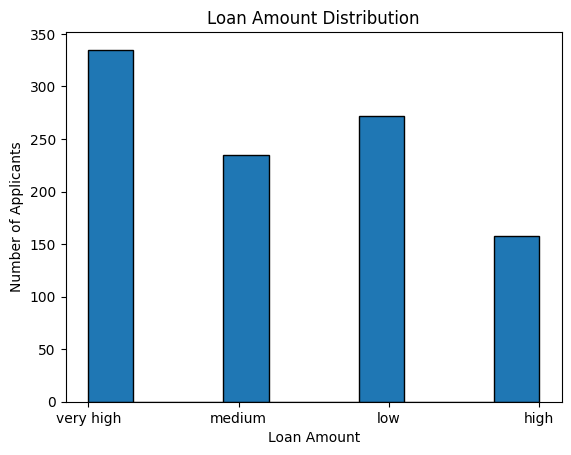

In [29]:
plt.hist(new_df["Loan_Range"],edgecolor="black")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.title("Loan Amount Distribution")
plt.show()

## Visual 2
- Affordability Ratio Distribution


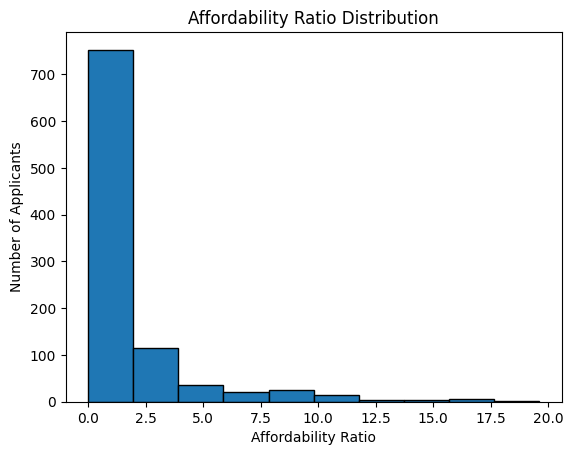

In [47]:
finite_affordability_ratio = new_df[(new_df["Affordability_Ratio"] !=np.inf )& (new_df["Affordability_Ratio"]<=20.0)]
plt.hist(finite_affordability_ratio["Affordability_Ratio"],edgecolor="black")
plt.xlabel("Affordability Ratio")
plt.ylabel("Number of Applicants")
plt.title("Affordability Ratio Distribution")
plt.show()

## Visual 3
- Utility Function Curve


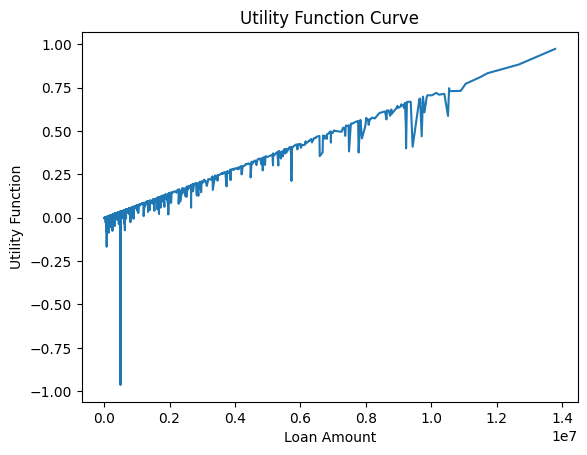

In [67]:
sorted_df = clean_df.sort_values(by="Loan_Amount")

plt.plot(sorted_df["Loan_Amount"],sorted_df["util_function"])
plt.xlabel("Loan Amount")
plt.ylabel("Utility Function")
plt.title("Utility Function Curve")
plt.show()